In [1]:
!pip install ultralytics
!pip install roboflow
!pip install grad-cam
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 9.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 10.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is t

In [2]:
import torch
import os 
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import cv2 
import yaml 
import glob 
import numpy as np
import matplotlib.pyplot as plt 
import random
import torch.nn as nn

from ultralytics import YOLO
from PIL import Image
from roboflow import Roboflow
from torchvision import transforms
from skimage.transform import resize
from tqdm import tqdm

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
SEED = 42 

In [4]:
import torch
import numpy as np
import random
import os

def set_seed(seed):
    # Python & OS
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Deterministic CUDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Global seed set to: {seed}")

set_seed(SEED)

Global seed set to: 42


In [5]:
rf = Roboflow(api_key="sNwZKFyXE0vHSdAqPXX0")
project = rf.workspace("main-workspace-vcien").project("birdnest-balanced-classification")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BirdNest-Balanced-Classification-1 in folder:: 100%|██████████| 817/817 [00:00<00:00, 3643.32it/s]


# Preprocessing & Augmentation 

## HITL Splitting from Roboflow

In [6]:
import os
import shutil
import random
from glob import glob
from PIL import Image
from roboflow import Roboflow

# --- Configuration ---
TARGET_SIZE = (640, 640)
OUTPUT_ROOT = "dataset_hitl"

# Global Split Ratios (Must sum to <= 1.0)
RATIO_TEST = 0.20     # 20% Global Test
RATIO_LABELED = 0.15  # 15% Initial Seed
# Remainder (65%) goes to Unlabeled Pool

# Labeled Split Ratios (Inside the 15% seed)
RATIO_LABELED_TRAIN = 0.80 # 80% of the seed goes to train
# Remainder (20%) of the seed goes to val

# --- 1. Download Dataset ---
print("Downloading dataset from Roboflow...")
rf = Roboflow(api_key="sNwZKFyXE0vHSdAqPXX0")
project = rf.workspace("main-workspace-vcien").project("birdnest-balanced-classification")
version = project.version(1)
dataset = version.download("folder")

print(f"Dataset downloaded to: {dataset.location}")

# --- 2. Setup Directories ---
def make_dirs(path):
    os.makedirs(path, exist_ok=True)

# Define paths - test is now inside labeled
dirs_to_create = [
    f"{OUTPUT_ROOT}/labeled/train",
    f"{OUTPUT_ROOT}/labeled/val",
    f"{OUTPUT_ROOT}/labeled/test",  # Changed: test is now inside labeled
    f"{OUTPUT_ROOT}/unlabeled"
]

# We need subfolders 0, 1, 2 for labeled/train, labeled/val, and labeled/test
for d in dirs_to_create[:3]:
    for i in range(3):
        make_dirs(f"{d}/{i}")
make_dirs(f"{OUTPUT_ROOT}/unlabeled") # Unlabeled is flat

# --- 3. Helper Functions ---
def resize_and_save(src_path, dest_path, size):
    try:
        with Image.open(src_path) as img:
            # Convert to RGB to avoid errors with PNG/RGBA
            img = img.convert('RGB')
            resized_img = img.resize(size, Image.Resampling.LANCZOS)
            resized_img.save(dest_path, quality=95)
    except Exception as e:
        print(f"Error processing {src_path}: {e}")

# --- 4. Processing Logic ---
random.seed(SEED)

# Find all class folders in the downloaded dataset
raw_classes = set()
for root, dirs, files in os.walk(dataset.location):
    if len(files) > 0:
        folder_name = os.path.basename(root)
        if folder_name not in ['train', 'valid', 'test']:
            raw_classes.add(folder_name)

# Sort classes alphabetically to ensure deterministic mapping
sorted_classes = sorted(list(raw_classes))
class_map = {name: str(idx) for idx, name in enumerate(sorted_classes)}

print(f"Detected Classes Mapping: {class_map}")

global_unlabeled_counter = 0

for class_name, class_idx in class_map.items():
    print(f"\nProcessing Class: {class_name} (Mapped to {class_idx})")
    
    # Gather ALL images for this class
    all_images = []
    for split in ['train', 'valid', 'test']:
        search_path = os.path.join(dataset.location, split, class_name)
        if os.path.exists(search_path):
            images = glob(os.path.join(search_path, "*"))
            all_images.extend(images)
            
    # Remove duplicates
    all_images = list(set(all_images))
    
    # Sort deterministically BEFORE shuffling
    all_images.sort()
    
    # Shuffle deterministically
    random.shuffle(all_images)
    
    total_imgs = len(all_images)
    
    # --- Calculate Counts ---
    count_test = int(total_imgs * RATIO_TEST)
    count_labeled = int(total_imgs * RATIO_LABELED)
    
    # Split the list
    imgs_test = all_images[:count_test]
    imgs_labeled = all_images[count_test : count_test + count_labeled]
    imgs_unlabeled = all_images[count_test + count_labeled :]
    
    # Further split Labeled into Train/Val
    count_labeled_train = int(len(imgs_labeled) * RATIO_LABELED_TRAIN)
    imgs_labeled_train = imgs_labeled[:count_labeled_train]
    imgs_labeled_val = imgs_labeled[count_labeled_train:]
    
    print(f"  - Total: {total_imgs}")
    print(f"  - Test: {len(imgs_test)}")
    print(f"  - Labeled Train: {len(imgs_labeled_train)}")
    print(f"  - Labeled Val: {len(imgs_labeled_val)}")
    print(f"  - Unlabeled Pool: {len(imgs_unlabeled)}")
    
    # --- Move and Resize ---
    
    # 1. Test Set - now goes to labeled/test
    for src in imgs_test:
        fname = os.path.basename(src)
        dst = os.path.join(OUTPUT_ROOT, "labeled", "test", class_idx, fname)  # Changed path
        resize_and_save(src, dst, TARGET_SIZE)
        
    # 2. Labeled Train
    for src in imgs_labeled_train:
        fname = os.path.basename(src)
        dst = os.path.join(OUTPUT_ROOT, "labeled", "train", class_idx, fname)
        resize_and_save(src, dst, TARGET_SIZE)
        
    # 3. Labeled Val
    for src in imgs_labeled_val:
        fname = os.path.basename(src)
        dst = os.path.join(OUTPUT_ROOT, "labeled", "val", class_idx, fname)
        resize_and_save(src, dst, TARGET_SIZE)
        
    # 4. Unlabeled Pool (Renaming with Ground Truth)
    for src in imgs_unlabeled:
        fname = os.path.basename(src)
        
        # New Format: (0)_original_filename.jpg
        # This keeps the ground truth '0' visible to YOU, but the file is in the generic 'unlabeled' folder.
        new_name = f"({class_idx})_{fname}"
        
        dst = os.path.join(OUTPUT_ROOT, "unlabeled", new_name)
        resize_and_save(src, dst, TARGET_SIZE)
        global_unlabeled_counter += 1

print("\nProcessing Complete.")
print(f"Unlabeled pool contains {global_unlabeled_counter} images.")
print(f"Data ready in folder: {OUTPUT_ROOT}")

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /kaggle/working/BirdNest-Balanced-Classification-1
Detected Classes Mapping: {'0': '0', '1': '1', '2': '2', 'BirdNest-Balanced-Classification-1': '3'}

Processing Class: 0 (Mapped to 0)
  - Total: 262
  - Test: 52
  - Labeled Train: 31
  - Labeled Val: 8
  - Unlabeled Pool: 171

Processing Class: 1 (Mapped to 1)
  - Total: 278
  - Test: 55
  - Labeled Train: 32
  - Labeled Val: 9
  - Unlabeled Pool: 182

Processing Class: 2 (Mapped to 2)
  - Total: 271
  - Test: 54
  - Labeled Train: 32
  - Labeled Val: 8
  - Unlabeled Pool: 177

Processing Class: BirdNest-Balanced-Classification-1 (Mapped to 3)
  - Total: 0
  - Test: 0
  - Labeled Train: 0
  - Labeled Val: 0
  - Unlabeled Pool: 0

Processing Complete.
Unlabeled pool contains 530 images.
Data ready in folder: dataset_hitl


In [7]:
import os

# Configuration
DATASET_ROOT = "dataset_hitl"
CLASSES = ['0', '1', '2']

def count_files(directory):
    """Counts image files in a directory."""
    if not os.path.exists(directory):
        return 0
    return len([
        f for f in os.listdir(directory) 
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ])

def get_counts_dict(base_path):
    """Returns a dict of counts {'0': x, '1': x, '2': x} and the total."""
    counts = {}
    total = 0
    for cls in CLASSES:
        path = os.path.join(base_path, cls)
        c = count_files(path)
        counts[cls] = c
        total += c
    return counts, total

def get_unlabeled_counts(directory):
    """Parses filenames starting with (0), (1), (2) to count classes in a flat folder."""
    counts = {'0': 0, '1': 0, '2': 0}
    total = 0
    
    if os.path.exists(directory):
        files = [f for f in os.listdir(directory) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for f in files:
            # Check prefix like "(0)_image.jpg"
            if f.startswith('(0)'):
                counts['0'] += 1
            elif f.startswith('(1)'):
                counts['1'] += 1
            elif f.startswith('(2)'):
                counts['2'] += 1
            total += 1
            
    return counts, total

def print_section(title, counts_dict, total):
    """Helper to format the output line nicely."""
    details = ", ".join([f"{k}: {v:>3}" for k, v in counts_dict.items()])
    print(f"{title:<10} | {details}  (Total: {total})")

# --- Main Execution ---
print(f"\n{'='*60}")
print(f"DATASET DISTRIBUTION SUMMARY: {DATASET_ROOT}")
print(f"{'='*60}\n")

# 1. Labeled Data
print("LABELED:")
print("-" * 60)

# Train
train_counts, train_total = get_counts_dict(os.path.join(DATASET_ROOT, "labeled", "train"))
print_section("Train", train_counts, train_total)

# Val
val_counts, val_total = get_counts_dict(os.path.join(DATASET_ROOT, "labeled", "val"))
print_section("Val", val_counts, val_total)

print("\n")

# 2. Test Data
print("TEST:")
print("-" * 60)
test_counts, test_total = get_counts_dict(os.path.join(DATASET_ROOT, "test"))
print_section("Test", test_counts, test_total)

print("\n")

# 3. Unlabeled Data
print("UNLABELED POOL:")
print("-" * 60)
unlabeled_path = os.path.join(DATASET_ROOT, "unlabeled")
pool_counts, pool_total = get_unlabeled_counts(unlabeled_path)
print_section("Pool Size", pool_counts, pool_total)

print(f"\n{'='*60}\n")


DATASET DISTRIBUTION SUMMARY: dataset_hitl

LABELED:
------------------------------------------------------------
Train      | 0:  31, 1:  32, 2:  32  (Total: 95)
Val        | 0:   8, 1:   9, 2:   8  (Total: 25)


TEST:
------------------------------------------------------------
Test       | 0:   0, 1:   0, 2:   0  (Total: 0)


UNLABELED POOL:
------------------------------------------------------------
Pool Size  | 0: 171, 1: 182, 2: 177  (Total: 530)




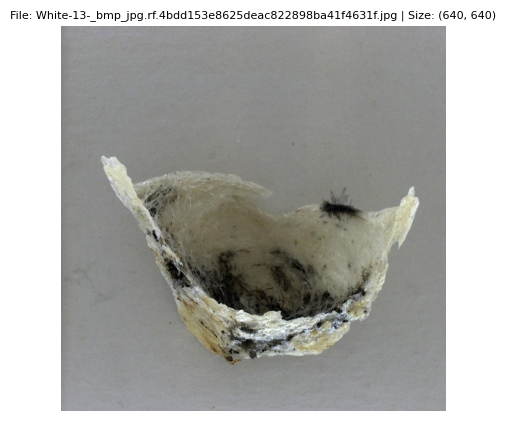

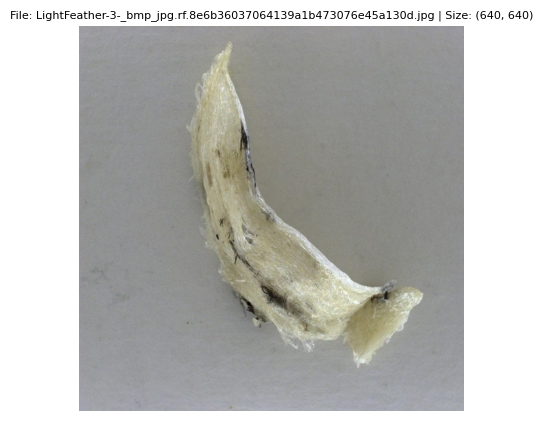

In [8]:
## Dataset Check Check

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def display_samples(target_folder, num_images=2):
    if not os.path.exists(target_folder):
        print(f"Directory not found: {target_folder}")
        return

    # Filter and sort (sorting ensures random.sample is consistent with a seed)
    all_files = sorted([f for f in os.listdir(target_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    # Use a fixed seed if you want to see the same "random" images every time 
    random.seed(SEED)
    samples = random.sample(all_files, min(len(all_files), num_images))

    for file_name in samples:
        img_path = os.path.join(target_folder, file_name)
        img = Image.open(img_path)
        
        plt.figure(figsize=(5, 5)) 
        plt.imshow(img)
        
        # Reduced fontsize for a cleaner research look
        plt.title(f"File: {file_name} | Size: {img.size}", fontsize=8) 
        plt.axis('off')
        plt.show()

display_samples('/kaggle/working/dataset_hitl/labeled/train/0', num_images=2)

# Initial Model Training

In [ ]:
model = YOLO("yolo11m-cls.pt")

In [ ]:
# set_seed(SEED)
model.train(
    data="/kaggle/working/dataset_hitl/labeled", 
    epochs=50, 
    patience=0,
    imgsz=640, 
    seed=SEED,
    deterministic=True,
    # Augmentations 
    fliplr=0.5,    # Horizontal Flip 
    flipud=0.0,    # Vertical Flip 
    degrees=15.0,  # Rotation 
    hsv_h=0.028,   # Hue 
    hsv_s=0.2,     # Saturation 
    hsv_v=0.2,     # Brightness
)

# Initial Model Testing

In [ ]:
# loaded_model = YOLO("/kaggle/working/runs/classify/train2/weights/best.pt")

In [17]:
loaded_model = YOLO("/kaggle/input/hitl-bests/pytorch/default/1/bests.pt", task='classify')
# loaded_model = YOLO("/kaggle/input/hitl-bestm/pytorch/default/1/bestm.pt", task='classify')

In [18]:
metrics = loaded_model.val(data="/kaggle/working/dataset_hitl/labeled", split="test", plots=True, seed=SEED, deterministic=True)

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s-cls summary (fused): 47 layers, 5,437,971 parameters, 0 gradients, 12.0 GFLOPs
train: /kaggle/working/dataset_hitl/labeled/train... found 95 images in 3 classes ✅ 
val: /kaggle/working/dataset_hitl/labeled/val... found 25 images in 3 classes ✅ 
test: /kaggle/working/dataset_hitl/labeled/test... found 161 images in 3 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2396.4±621.5 MB/s, size: 115.5 KB)
test: Scanning /kaggle/working/dataset_hitl/labeled/test... 161 images, 0 corrupt: 100% ━━━━━━━━━━━━ 161/161 67.5Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 11/11 5.7it/s 1.9s0.1s
                   all      0.646          1
Speed: 3.1ms preprocess, 4.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val3


In [19]:
print(metrics.results_dict)

{'metrics/accuracy_top1': 0.6459627151489258, 'metrics/accuracy_top5': 1.0, 'fitness': 0.8229813575744629}


In [20]:
top1_accuracy = metrics.results_dict["metrics/accuracy_top1"]

print(f"Model Accuracy: {top1_accuracy}")

Model Accuracy: 0.6459627151489258


# Initial Model Predictions

In [21]:
from ultralytics import YOLO
import os
import pandas as pd

# --- Configuration ---
UNLABELED_PATH = "/kaggle/working/dataset_hitl/unlabeled"
OUTPUT_CSV = "predictions.csv"

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

data_rows = []

print(f"Running predictions on {UNLABELED_PATH}...")

# 2. Loop & Predict
for filename in sorted(os.listdir(UNLABELED_PATH)):
    if filename.lower().endswith(valid_extensions):
        image_path = os.path.join(UNLABELED_PATH, filename)
        
        # Run inference
        results = loaded_model(image_path, verbose=False)
        
        for result in results:
            # Extract Probabilities
            probs = result.probs.data.tolist()
            sorted_probs = sorted(probs, reverse=True)
            
            top1_conf = sorted_probs[0]
            top2_conf = sorted_probs[1]
            margin = top1_conf - top2_conf
            
            top_class_idx = result.probs.top1
            class_name = result.names[top_class_idx]
            
            # --- STORE EVERYTHING USEFUL HERE ---
            data_rows.append({
                "filename": filename,
                "filepath": image_path,           
                "predicted_class": class_name,
                "confidence": round(top1_conf, 4),
                "margin": round(margin, 4),
                "probs": probs                     
            })

# 3. Create DataFrame and Store in Variable
unlabeled_df = pd.DataFrame(data_rows)

# Save to CSV for backup
unlabeled_df.to_csv(OUTPUT_CSV, index=False)

print(f"\nSuccess! Predictions stored in variable 'unlabeled_df'")
print(f"Saved backup to {OUTPUT_CSV}")

Running predictions on /kaggle/working/dataset_hitl/unlabeled...

Success! Predictions stored in variable 'unlabeled_df'
Saved backup to predictions.csv


Generating Grad-CAM Maps for 16 images...


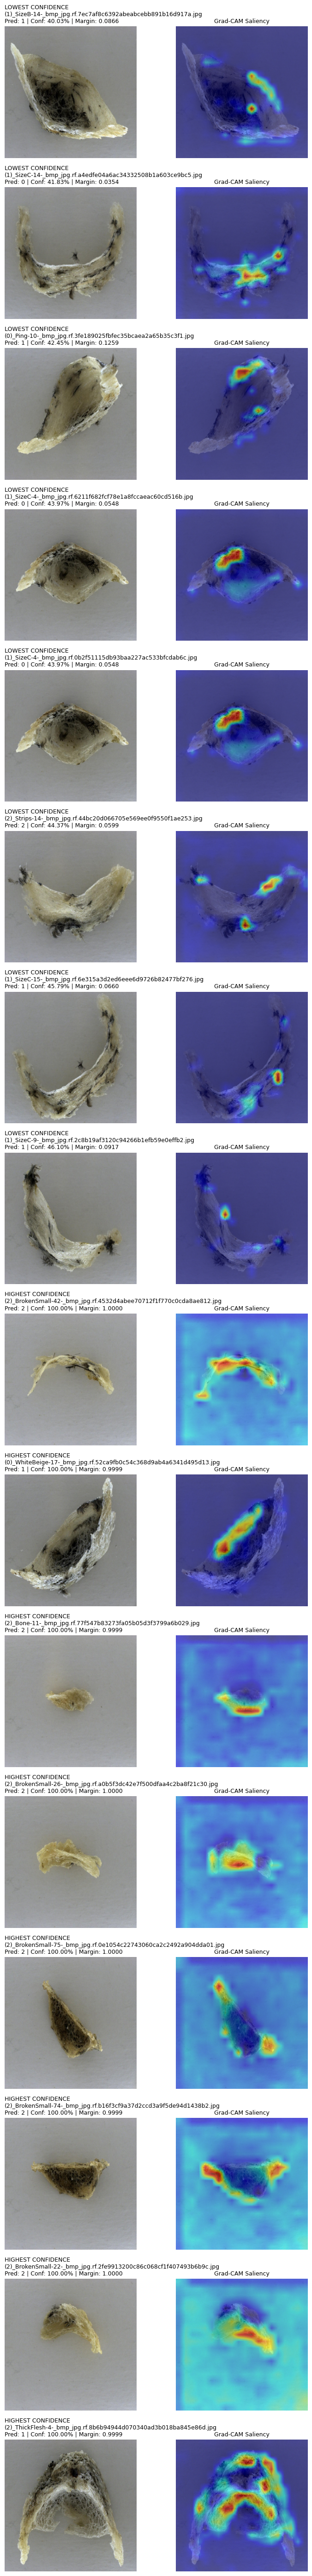

In [28]:
import copy
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# Standard CAM imports
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from ultralytics.data.augment import classify_transforms

# 1. CAM Setup
# ----------------------------------
# Copy the underlying PyTorch model
torch_model = copy.deepcopy(loaded_model.model) 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch_model.to(device)

# UNFREEZE THE MODEL (Critical for Grad-CAM)
for param in torch_model.parameters():
    param.requires_grad = True
    
torch_model.eval()

# Wrapper to handle YOLO's output format
class YOLOWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        res = self.model(x)
        return res[0] if isinstance(res, (list, tuple)) else res

wrapped_model = YOLOWrapper(torch_model)

# Target the bottleneck layer
target_layers = [torch_model.model[-2]]

# Initialize ONLY GradCAM
grad_cam = GradCAM(model=wrapped_model, target_layers=target_layers)

# 2. Select Images (Using 'unlabeled_df')
# ----------------------------------
sorted_df = unlabeled_df.sort_values(by="confidence", ascending=True)

# Select top 8 lowest (Hardest) and top 8 highest (Easiest)
lowest_conf_samples = sorted_df.head(8)
highest_conf_samples = sorted_df.tail(8) 

selected_samples = pd.concat([lowest_conf_samples, highest_conf_samples])

# 3. Visualization Function
# ----------------------------------
def generate_cam_row(row_data, model_instance):
    img_path = row_data['filepath']
    
    # Preprocessing
    img_cv2 = cv2.imread(img_path)
    if img_cv2 is None: return None
    img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    
    # Input Tensor
    transform = classify_transforms(size=640)
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    input_tensor.requires_grad = True
    
    # Prediction details
    pred_class_name = row_data['predicted_class']
    pred_class_idx = list(model_instance.names.values()).index(pred_class_name)
    
    # Background for overlay
    img_for_overlay = cv2.resize(img_rgb, (640, 640))
    rgb_background = np.float32(img_for_overlay) / 255
    
    # --- Run Grad-CAM ---
    targets = [ClassifierOutputTarget(pred_class_idx)]
    grayscale_grad = grad_cam(input_tensor=input_tensor, targets=targets)[0, :]
    vis_grad = show_cam_on_image(rgb_background, grayscale_grad, use_rgb=True)
    
    # Resize for display (320x320)
    display_size = (320, 320)
    orig_display = cv2.resize(img_rgb, display_size)
    vis_grad_display = cv2.resize(vis_grad, display_size)
    
    return orig_display, vis_grad_display

# 4. Plotting Loop
# ----------------------------------
rows = len(selected_samples)
cols = 2  # Changed to 2 columns
fig, axes = plt.subplots(rows, cols, figsize=(8, 3.5 * rows)) # Adjusted width

print(f"Generating Grad-CAM Maps for {rows} images...")

for idx, (df_index, row_data) in enumerate(selected_samples.iterrows()):
    try:
        group_label = "LOWEST CONFIDENCE" if idx < 8 else "HIGHEST CONFIDENCE"
        
        # Generate Visuals
        res = generate_cam_row(row_data, loaded_model)
        if res is None: continue
        orig, vis_grad = res
        
        # Metadata
        fname = row_data['filename']
        pred = row_data['predicted_class']
        conf = row_data['confidence']
        margin = row_data['margin']
        
        title_text = f"{group_label}\n{fname}\nPred: {pred} | Conf: {conf:.2%} | Margin: {margin:.4f}"
        
        # Plot Original
        axes[idx, 0].imshow(orig)
        axes[idx, 0].set_title(title_text, fontsize=9, loc='left')
        axes[idx, 0].axis('off')
        
        # Plot Grad-CAM
        axes[idx, 1].imshow(vis_grad)
        axes[idx, 1].set_title("Grad-CAM Saliency", fontsize=9)
        axes[idx, 1].axis('off')
        
    except Exception as e:
        print(f"Error processing row {idx}: {e}")

plt.tight_layout()
plt.show()

# HITL 

In [46]:
import gradio as gr
import cv2
import numpy as np
import random
import torch
import copy
from PIL import Image

# --- New Imports for Model/CAM ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from ultralytics.data.augment import classify_transforms

# ==========================================
# 1. GLOBAL MODEL & CAM SETUP
# ==========================================
try:
    # We assume 'loaded_model' is already defined in your notebook
    torch_model = copy.deepcopy(loaded_model.model) 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch_model.to(device)

    # UNFREEZE for Grad-CAM
    for param in torch_model.parameters():
        param.requires_grad = True
    torch_model.eval()

    # Wrapper for CAM
    class YOLOWrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        def forward(self, x):
            res = self.model(x)
            return res[0] if isinstance(res, (list, tuple)) else res

    wrapped_model = YOLOWrapper(torch_model)
    target_layers = [torch_model.model[-2]]
    grad_cam = GradCAM(model=wrapped_model, target_layers=target_layers)
    print("Model and Grad-CAM initialized successfully.")
except NameError:
    print("Warning: 'loaded_model' not found. Prediction features will be disabled.")

# ==========================================
# 2. CAIPI GENERATOR CLASS (Unchanged)
# ==========================================
class CAIPIGenerator:
    def __init__(self):
        pass

    def get_nest_mask(self, image, red_mask):
        h, w = image.shape[:2]
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sobelx, sobely)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        kernel_close = np.ones((25, 25), np.uint8) 
        solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
        
        kernel_open = np.ones((5, 5), np.uint8)
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel_open, iterations=2)
        
        contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_mask = np.zeros((h, w), dtype=np.uint8)
        
        if contours:
            largest = max(contours, key=cv2.contourArea)
            epsilon = 0.002 * cv2.arcLength(largest, True)
            approx = cv2.approxPolyDP(largest, epsilon, True)
            cv2.drawContours(valid_mask, [approx], -1, 255, thickness=cv2.FILLED)

        valid_mask = cv2.erode(valid_mask, np.ones((5, 5), np.uint8), iterations=1)

        if np.count_nonzero(red_mask) > 0:
            valid_mask = cv2.bitwise_and(valid_mask, cv2.bitwise_not(red_mask))
            
        return valid_mask

    def background_intervention(self, image, mask):
        if np.count_nonzero(mask) == 0:
            return image 
        noise = np.random.randint(0, 256, image.shape, dtype=np.uint8)
        binary_mask = mask > 127
        output = image.copy()
        output[binary_mask] = noise[binary_mask]
        return output

    def destructive_intervention_scatter(self, image, green_mask, red_mask, clones_per_source=4):
        if np.count_nonzero(green_mask) == 0:
            return image
            
        output = image.copy()
        h_img, w_img = image.shape[:2]
        
        valid_zone = self.get_nest_mask(image, red_mask)
        valid_zone = cv2.erode(valid_zone, np.ones((10, 10), np.uint8), iterations=2)
        
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) < 10:
                continue
                
            x, y, w, h = cv2.boundingRect(cnt)
            roi = image[y:y+h, x:x+w].copy()
            roi_green_mask = green_mask[y:y+h, x:x+w]
            roi_mask = np.zeros((h, w), dtype=np.uint8)
            roi_mask[roi_green_mask > 0] = 255
            
            num_clones = clones_per_source 
            clones_placed = 0
            attempts = 0
            max_attempts = 200 + (num_clones * 10) 
            
            while clones_placed < num_clones and attempts < max_attempts:
                attempts += 1
                spread_factor = 80 + (num_clones * 2) 
                offset_x = random.randint(-spread_factor, spread_factor)
                offset_y = random.randint(-spread_factor, spread_factor)
                center_x = x + w//2 + offset_x
                center_y = y + h//2 + offset_y
                tl_x = center_x - w // 2
                tl_y = center_y - h // 2
                br_x = tl_x + w
                br_y = tl_y + h
                
                margin = 5
                if (tl_x < margin or tl_y < margin or br_x > w_img - margin or br_y > h_img - margin):
                    continue
                
                try:
                    valid_zone_region = valid_zone[tl_y:br_y, tl_x:br_x]
                    if valid_zone_region.shape != roi_mask.shape:
                        continue
                    impurity_pixels = roi_mask > 0
                    invalid_placements = np.sum(impurity_pixels & (valid_zone_region == 0))
                    if invalid_placements > 0:
                        continue
                except Exception as e:
                    continue 
    
                try:
                    output = cv2.seamlessClone(roi, output, roi_mask, (center_x, center_y), cv2.MIXED_CLONE)
                    clones_placed += 1
                except Exception as e:
                    pass
                    
        return output

    def restorative_intervention_texture(self, image, mask):
        if np.count_nonzero(mask) == 0:
            return image
        
        output = cv2.inpaint(image, mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)
        output = cv2.bilateralFilter(output, d=7, sigmaColor=75, sigmaSpace=75)
        kernel_sharpen = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]]) / 1.0
        sharpened = cv2.filter2D(output, -1, kernel_sharpen)
        mask_3ch = np.stack([mask] * 3, axis=-1) / 255.0
        output = (sharpened * mask_3ch + output * (1 - mask_3ch)).astype(np.uint8)
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        texture_strength = np.std(gray)
        noise = np.random.normal(0, texture_strength * 0.15, output.shape).astype(np.int16)
        output = np.clip(output.astype(np.int16) + noise * mask_3ch, 0, 255).astype(np.uint8)
        return output

generator = CAIPIGenerator()

Model and Grad-CAM initialized successfully.


In [47]:
# ==========================================
# 3. ANALYSIS FUNCTION (Step 1: Predict First)
# ==========================================
def analyze_image(input_dict):
    """
    Reads the 'background' image from the editor (ignoring user drawing),
    runs YOLO prediction, and generates Saliency Map.
    """
    if input_dict is None: return None, "No Image Loaded"

    # --- A. PREPARE IMAGE ---
    # We use the background because we want to analyze the raw image before edits
    original_img = input_dict["background"]
    if original_img.shape[2] == 4: 
        original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
    original_img = original_img.astype(np.uint8)
    
    # --- B. MODEL PREDICTION ---
    img_pil = Image.fromarray(original_img)
    
    results = loaded_model(img_pil, verbose=False)
    probs = results[0].probs.data.tolist()
    sorted_probs = sorted(probs, reverse=True)
    top1_conf = sorted_probs[0]
    top2_conf = sorted_probs[1]
    margin = top1_conf - top2_conf
    pred_idx = results[0].probs.top1
    pred_class = results[0].names[pred_idx]
    
    stats_text = (
        f"**Prediction:** {pred_class}\n\n"
        f"**Confidence:** {top1_conf:.2%}\n\n"
        f"**Margin:** {margin:.4f}"
    )

    # --- C. GRAD-CAM SALIENCY ---
    transform = classify_transforms(size=640)
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    input_tensor.requires_grad = True
    
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = grad_cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Overlay Saliency on original
    img_for_overlay = cv2.resize(original_img, (640, 640))
    rgb_background = np.float32(img_for_overlay) / 255
    vis_cam = show_cam_on_image(rgb_background, grayscale_cam, use_rgb=True)

    return vis_cam, stats_text

# ==========================================
# 4. GENERATION FUNCTION (Step 2: Generate Second)
# ==========================================
def process_caipi_generation(input_dict):
    """
    Reads the 'layers' (drawn masks) from the editor to generate counterfactuals.
    """
    if input_dict is None: return []

    original_img = input_dict["background"]
    if original_img.shape[2] == 4: original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
    original_img = original_img.astype(np.uint8)
    
    # Decode Masks (Your original logic)
    drawing_layer = input_dict["layers"][0]
    r = drawing_layer[:, :, 0]
    g = drawing_layer[:, :, 1]
    a = drawing_layer[:, :, 3]
    
    drawn = a > 10
    mask_red = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_green = np.zeros(original_img.shape[:2], dtype=np.uint8)
    
    # Red > Green = Background Mask
    mask_red[(r > g) & drawn] = 255
    # Green > Red = Impurity Mask
    mask_green[(g > r) & drawn] = 255

    outputs = []
    
    # 1. Background Noise
    outputs.append((generator.background_intervention(original_img, mask_red), "Background Noise"))

    # 2. Destructive Scatter
    severity_levels = [2, 5, 10, 20, 40]
    for level in severity_levels:
        result = generator.destructive_intervention_scatter(
            original_img, mask_green, mask_red, clones_per_source=level
        )
        outputs.append((result, f"Scatter Lvl {level}"))

    # 3. Restorative
    outputs.append((generator.restorative_intervention_texture(original_img, mask_green), "Restored"))

    # 4. Debug Mask
    outputs.append((generator.get_nest_mask(original_img, mask_red), "Safe Zone"))

    return outputs

# ==========================================
# 5. UI LAYOUT
# ==========================================
with gr.Blocks(title="CAIPI: Integrated HITL") as demo:
    gr.Markdown("## CAIPI: Human-in-the-Loop Counterfactual Generator")
    
    with gr.Row():
        # LEFT: INPUT & BUTTONS
        with gr.Column(scale=1):
            image_input = gr.ImageEditor(
                type="numpy", 
                label="Annotation Canvas",
                brush=gr.Brush(colors=["#90EE9080", "#FF999980"], default_size=15),
                interactive=True
            )
            gr.Markdown("**Red:** Background | **Green:** Impurities")
            
            with gr.Row():
                btn_analyze = gr.Button("1. Predict & Diagnose", variant="primary")
                btn_generate = gr.Button("2. Generate Counterfactuals", variant="secondary")
        
        # RIGHT: OUTPUTS
        with gr.Column(scale=1):
            with gr.Row():
                cam_output = gr.Image(label="Saliency Map", height=300)
                stats_output = gr.Markdown(label="Prediction Stats")
            
            gallery_output = gr.Gallery(label="Counterfactual Results", columns=4, height=500)

    # ACTIONS
    # Step 1: Analyze (Reads clean image)
    btn_analyze.click(
        fn=analyze_image,
        inputs=[image_input],
        outputs=[cam_output, stats_output]
    )
    
    # Step 2: Generate (Reads drawings)
    btn_generate.click(
        fn=process_caipi_generation,
        inputs=[image_input],
        outputs=[gallery_output]
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7868
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://d47d5549f73bb9c953.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
